## ⚙️ **Libraries Import**

In [164]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.6.0+cu124
Device: cpu


In [165]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/the-pirate-pain-dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/the-pirate-pain-dataset/sample_submission.csv
/kaggle/input/the-pirate-pain-dataset/pirate_pain_test.csv
/kaggle/input/the-pirate-pain-dataset/pirate_pain_train_labels.csv
/kaggle/input/the-pirate-pain-dataset/pirate_pain_train.csv


## ⏳ **Data Loading**

In [166]:
os.environ["DATASETS"] = "/kaggle/input/the-pirate-pain-dataset"
os.environ["DATASET_train"] = "/kaggle/input/the-pirate-pain-dataset/pirate_pain_train.csv"
os.environ["DATASET_test"] = "/kaggle/input/the-pirate-pain-dataset/pirate_pain_test.csv"
os.environ["DATASET_train-labels"] = "/kaggle/input/the-pirate-pain-dataset/pirate_pain_train_labels.csv"

## 🔎 **Exploration and Data Analysis**

In [167]:
# Load the dataset from a CSV file
df_train = pd.read_csv(os.environ["DATASET_train"])
df_public_test = pd.read_csv(os.environ["DATASET_test"])
df_labels = pd.read_csv(os.environ["DATASET_train-labels"])

# Print the shape of the DataFrame
# print(f"DataFrame shape: {dataset}")

In [168]:
# Get unique user IDs and shuffle them
unique_users = df_train['sample_index'].unique()
random.seed(SEED)   # Ensure reproducibility
random.shuffle(unique_users)

#20%
# Define the number of users for test
N_TEST_USERS = 132

# Define the number of users for validation
N_VAL_USERS = 132

# Calculate the number of users for the training set
n_train_users = len(unique_users) - N_VAL_USERS - N_TEST_USERS

# Split the shuffled user IDs into training and validation sets
train_users = unique_users[:n_train_users]
val_users = unique_users[n_train_users:n_train_users + N_VAL_USERS]
test_users = unique_users[n_train_users + N_VAL_USERS:]

print(len(train_users))
print(len(test_users))
print(len(val_users))

df_train_full = df_train.copy()

df_train = df_train_full[df_train_full['sample_index'].isin(train_users)]
df_test = df_train_full[df_train_full['sample_index'].isin(test_users)]
df_val   = df_train_full[df_train_full['sample_index'].isin(val_users)]


397
132
132


In [169]:
# Display the first 10 rows of the DataFrame
# Display a summary of the dataset's structure and data types
df_train.info()
df_train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 63520 entries, 160 to 105439
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_index   63520 non-null  int64  
 1   time           63520 non-null  int64  
 2   pain_survey_1  63520 non-null  int64  
 3   pain_survey_2  63520 non-null  int64  
 4   pain_survey_3  63520 non-null  int64  
 5   pain_survey_4  63520 non-null  int64  
 6   n_legs         63520 non-null  object 
 7   n_hands        63520 non-null  object 
 8   n_eyes         63520 non-null  object 
 9   joint_00       63520 non-null  float64
 10  joint_01       63520 non-null  float64
 11  joint_02       63520 non-null  float64
 12  joint_03       63520 non-null  float64
 13  joint_04       63520 non-null  float64
 14  joint_05       63520 non-null  float64
 15  joint_06       63520 non-null  float64
 16  joint_07       63520 non-null  float64
 17  joint_08       63520 non-null  float64
 18  joint_09

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
160,1,0,2,1,2,2,two,two,two,1.233603,...,1.467248e-07,1.790415e-07,3.006389e-07,6.997916e-08,0.000000e+00,0.038205,0.071314,0.167005,0.071224,0.5
161,1,1,2,2,2,2,two,two,two,1.282773,...,1.453854e-07,4.260946e-07,3.030164e-07,1.749385e-06,3.593305e-07,0.042063,0.092794,0.313285,0.109012,0.5
162,1,2,2,2,2,2,two,two,two,1.152013,...,9.792152e-07,1.826749e-07,7.876740e-07,2.485037e-06,2.660860e-07,0.028804,0.114392,0.180912,0.057898,0.5
163,1,3,2,2,1,0,two,two,two,1.220093,...,2.461210e-06,6.828547e-07,1.654281e-06,8.159605e-08,0.000000e+00,0.013567,0.055338,0.177194,0.084191,0.5
164,1,4,2,2,2,2,two,two,two,1.099698,...,1.413512e-07,1.862835e-07,1.783894e-06,8.544108e-08,2.980574e-06,0.052765,0.040712,0.176549,0.082932,0.5


In [170]:
# Display the first 10 rows of the DataFrame
# Display a summary of the dataset's structure and data types
df_val.info()
df_val.head()

<class 'pandas.core.frame.DataFrame'>
Index: 21120 entries, 0 to 105279
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_index   21120 non-null  int64  
 1   time           21120 non-null  int64  
 2   pain_survey_1  21120 non-null  int64  
 3   pain_survey_2  21120 non-null  int64  
 4   pain_survey_3  21120 non-null  int64  
 5   pain_survey_4  21120 non-null  int64  
 6   n_legs         21120 non-null  object 
 7   n_hands        21120 non-null  object 
 8   n_eyes         21120 non-null  object 
 9   joint_00       21120 non-null  float64
 10  joint_01       21120 non-null  float64
 11  joint_02       21120 non-null  float64
 12  joint_03       21120 non-null  float64
 13  joint_04       21120 non-null  float64
 14  joint_05       21120 non-null  float64
 15  joint_06       21120 non-null  float64
 16  joint_07       21120 non-null  float64
 17  joint_08       21120 non-null  float64
 18  joint_09  

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5


In [171]:
# Display the first 10 rows of the DataFrame
# Display a summary of the dataset's structure and data types
df_test.info()
df_test.head()

<class 'pandas.core.frame.DataFrame'>
Index: 21120 entries, 480 to 105759
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_index   21120 non-null  int64  
 1   time           21120 non-null  int64  
 2   pain_survey_1  21120 non-null  int64  
 3   pain_survey_2  21120 non-null  int64  
 4   pain_survey_3  21120 non-null  int64  
 5   pain_survey_4  21120 non-null  int64  
 6   n_legs         21120 non-null  object 
 7   n_hands        21120 non-null  object 
 8   n_eyes         21120 non-null  object 
 9   joint_00       21120 non-null  float64
 10  joint_01       21120 non-null  float64
 11  joint_02       21120 non-null  float64
 12  joint_03       21120 non-null  float64
 13  joint_04       21120 non-null  float64
 14  joint_05       21120 non-null  float64
 15  joint_06       21120 non-null  float64
 16  joint_07       21120 non-null  float64
 17  joint_08       21120 non-null  float64
 18  joint_09

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
480,3,0,1,2,2,0,two,two,two,0.996243,...,1.139018e-07,1.802904e-06,2.588236e-06,1.715739e-06,0.000005,0.017648,0.044323,0.045728,0.041061,0.5
481,3,1,2,2,2,0,two,two,two,1.181797,...,1.185473e-07,2.669033e-06,1.711826e-06,1.617878e-07,0.000000,0.024723,0.061429,0.045817,0.040667,0.5
482,3,2,0,2,2,2,two,two,two,1.031544,...,2.237424e-06,2.245837e-07,3.451686e-07,1.291866e-06,0.000000,0.049924,0.057147,0.056711,0.030529,0.5
483,3,3,2,2,2,2,two,two,two,1.119454,...,1.097085e-07,2.258416e-07,2.205771e-06,5.654827e-07,0.000006,0.059655,0.115717,0.070853,0.076215,0.5
484,3,4,2,2,1,2,two,two,two,1.070587,...,6.701660e-06,1.511050e-06,8.525597e-07,6.561802e-07,0.000000,0.052700,0.110801,0.053447,0.031448,0.5


## 🔄 **Data Preprocessing**

In [172]:
# Map int64, float64, string to float32
mapping = {
    "one+peg_leg": 1,
    "one+hook_hand": 1,
    "one+eye_patch": 1,
    "two": 2,
}

# Train data
for col in df_train:
    if df_train[col].dtype == 'int64' and col not in ['sample_index', 'time']:
        df_train[col] = df_train[col].astype(np.float32)
    elif df_train[col].dtype == 'float64':
        df_train[col] = df_train[col].astype(np.float32)
    elif df_train[col].dtype == 'object':
        df_train[col] = df_train[col].replace(mapping)
        df_train[col] = df_train[col].astype(np.float32)

#Validation data
for col in df_val:
    if df_val[col].dtype == 'int64' and col not in ['sample_index', 'time']:
        df_val[col] = df_val[col].astype(np.float32)
    elif df_val[col].dtype == 'float64':
        df_val[col] = df_val[col].astype(np.float32)
    elif df_val[col].dtype == 'object':
        df_val[col] = df_val[col].replace(mapping)
        df_val[col] = df_val[col].astype(np.float32)
        
#Test data
for col in df_test:
    if df_test[col].dtype == 'int64' and col not in ['sample_index', 'time']:
        df_test[col] = df_test[col].astype(np.float32)
    elif df_test[col].dtype == 'float64':
        df_test[col] = df_test[col].astype(np.float32)
    elif df_test[col].dtype == 'object':
        df_test[col] = df_test[col].replace(mapping)
        df_test[col] = df_test[col].astype(np.float32)

#Public test data
for col in df_public_test:
    if df_public_test[col].dtype == 'int64' and col not in ['sample_index', 'time']:
        df_public_test[col] = df_public_test[col].astype(np.float32)
    elif df_public_test[col].dtype == 'float64':
        df_public_test[col] = df_public_test[col].astype(np.float32)
    elif df_public_test[col].dtype == 'object':
        df_public_test[col] = df_public_test[col].replace(mapping)
        df_public_test[col] = df_public_test[col].astype(np.float32)

In [173]:
# MAP labels
label_mapping = {label: idx for idx, label in enumerate(df_labels['label'].unique())}
df_labels['label_idx'] = df_labels['label'].map(label_mapping)
df_labels.drop('label', axis=1, inplace=True)
df_labels.head()

,sample_index,label_idx
0,0,0
1,1,0
2,2,1
3,3,0
4,4,0


In [174]:
# # One hot encode labels
# df_labels_onehot = pd.get_dummies(df_labels, columns=['label'])
# df_labels_onehot.head(10)

In [175]:
df_train.info()
df_train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 63520 entries, 160 to 105439
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_index   63520 non-null  int64  
 1   time           63520 non-null  int64  
 2   pain_survey_1  63520 non-null  float32
 3   pain_survey_2  63520 non-null  float32
 4   pain_survey_3  63520 non-null  float32
 5   pain_survey_4  63520 non-null  float32
 6   n_legs         63520 non-null  float32
 7   n_hands        63520 non-null  float32
 8   n_eyes         63520 non-null  float32
 9   joint_00       63520 non-null  float32
 10  joint_01       63520 non-null  float32
 11  joint_02       63520 non-null  float32
 12  joint_03       63520 non-null  float32
 13  joint_04       63520 non-null  float32
 14  joint_05       63520 non-null  float32
 15  joint_06       63520 non-null  float32
 16  joint_07       63520 non-null  float32
 17  joint_08       63520 non-null  float32
 18  joint_09

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
160,1,0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.233603,...,1.467248e-07,1.790415e-07,3.006389e-07,6.997916e-08,0.000000e+00,0.038205,0.071314,0.167005,0.071224,0.5
161,1,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.282773,...,1.453854e-07,4.260946e-07,3.030164e-07,1.749385e-06,3.593305e-07,0.042063,0.092794,0.313285,0.109012,0.5
162,1,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.152013,...,9.792152e-07,1.826749e-07,7.876740e-07,2.485037e-06,2.660860e-07,0.028804,0.114392,0.180912,0.057898,0.5
163,1,3,2.0,2.0,1.0,0.0,2.0,2.0,2.0,1.220093,...,2.461210e-06,6.828548e-07,1.654281e-06,8.159604e-08,0.000000e+00,0.013567,0.055338,0.177194,0.084191,0.5
164,1,4,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.099697,...,1.413513e-07,1.862835e-07,1.783894e-06,8.544108e-08,2.980574e-06,0.052765,0.040712,0.176549,0.082932,0.5


In [176]:
scale_columns = ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'n_legs', 'n_hands', 'n_eyes'] + [f'joint_{i:02d}' for i in range(0, 31)]
# print(scale_columns)
mins = df_train[scale_columns].min()
maxs = df_train[scale_columns].max()

for column in scale_columns:
    range_ = maxs[column] - mins[column]
    if range_ == 0:
        df_train[column] = 0
        df_val[column] = 0
        df_test[column] = 0
        df_public_test[column] = 0
    else:
        df_train[column] = (df_train[column] - mins[column]) / range_
        df_val[column] = (df_val[column] - mins[column]) / range_
        df_test[column] = (df_test[column] - mins[column]) / range_
        df_public_test[column] = (df_public_test[column] - mins[column]) / range_

In [177]:
# Display the first five rows of the training DataFrame
print(df_train.shape)
df_train.head()

(63520, 40)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
160,1,0,1.0,0.5,1.0,1.0,1.0,1.0,1.0,0.876159,...,1.017369e-07,2.144985e-08,0.000001,0.000002,0.000000e+00,0.031059,0.060934,0.118273,0.061755,0
161,1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.911081,...,1.008082e-07,2.107624e-07,0.000001,0.000048,3.792991e-07,0.034212,0.079288,0.221867,0.094519,0
162,1,2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.818209,...,6.789740e-07,2.423408e-08,0.000003,0.000068,2.808728e-07,0.023375,0.097741,0.128122,0.050201,0
163,1,3,1.0,1.0,0.5,0.0,1.0,1.0,1.0,0.866563,...,1.706569e-06,4.075133e-07,0.000006,0.000002,0.000000e+00,0.010920,0.047283,0.125488,0.072998,0
164,1,4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.781053,...,9.801096e-08,2.699930e-08,0.000007,0.000002,3.146209e-06,0.042960,0.034786,0.125032,0.071907,0


In [178]:
# List of feature columns
feature_cols = [col for col in df_train.columns if col not in ["sample_index", "time"]]

In [179]:
X_train = []
y_train = []

for sample_id, group in df_train.groupby("sample_index"):
    # sort by time
    group = group.sort_values("time")
    
    # features for this sample
    X_train.append(group[feature_cols].values)
    
    # corresponding integer label
    label_idx = df_labels.loc[df_labels["sample_index"] == sample_id, "label_idx"].values[0]
    y_train.append(label_idx)

# Convert to numpy arrays
X_train = np.array(X_train, dtype=np.float32)  # shape: (num_samples, seq_len, num_features)
y_train = np.array(y_train, dtype=np.int64)    # shape: (num_samples,)

In [180]:
X_val = []
y_val = []

for sample_id, group in df_val.groupby("sample_index"):
    # sort by time
    group = group.sort_values("time")
    
    # features for this sample
    X_val.append(group[feature_cols].values)
    
    # corresponding integer label
    label_idx = df_labels.loc[df_labels["sample_index"] == sample_id, "label_idx"].values[0]
    y_val.append(label_idx)

# Convert to numpy arrays
X_val = np.array(X_val, dtype=np.float32)  # shape: (num_samples, seq_len, num_features)
y_val = np.array(y_val, dtype=np.int64)    # shape: (num_samples,)


In [181]:
X_test = []
y_test = []

for sample_id, group in df_test.groupby("sample_index"):
    # sort by time
    group = group.sort_values("time")
    
    # features for this sample
    X_test.append(group[feature_cols].values)
    
    # corresponding integer label
    label_idx = df_labels.loc[df_labels["sample_index"] == sample_id, "label_idx"].values[0]
    y_test.append(label_idx)

# Convert to numpy arrays
X_test = np.array(X_test, dtype=np.float32)  # shape: (num_samples, seq_len, num_features)
y_test = np.array(y_test, dtype=np.int64)    # shape: (num_samples,)

In [182]:
print(len(X_val), len(y_val))  # should match
print(np.unique(y_val, return_counts=True))


132 132
(array([0, 1, 2]), array([95, 20, 17]))


In [183]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

In [184]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

In [185]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 512

In [186]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [187]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [188]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Features batch shape: torch.Size([397, 160, 38])
Labels batch shape: torch.Size([397])


## 🛠️ **Model Building**

In [189]:
def recurrent_summary(model, input_size):
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [190]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x)

        # LSTM returns (h_n, c_n), we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits


# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout_rate=0.,
    rnn_type='RNN'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (RNN)                 [[-1, 160, 128], [2, -1, 128]] 54,528         
classifier (Linear)       [-1, 3]                      387            
Total params: 54,915
Trainable params: 54,915
Non-trainable params: 0
-------------------------------------------------------------------------------


## 🧮 **Network and Training Hyperparameters**

In [191]:
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 100
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 0            # L2 penalty

# compute class weights
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # normalize

print("class weights:", class_weights)

# convert to tensor, used in loss function
weights = torch.tensor(class_weights, dtype=torch.float32)


# Set up loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=weights)

class weights: [0.05579306 0.31852764 0.6256793 ]


## 🧠 **Model Training**

In [192]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [193]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

        # print(f'targets:{targets}')
        # print(f'predictions:{predictions}')

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [194]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [195]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [196]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## LSTM

In [197]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=False,
    rnn_type='LSTM'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "lstm"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (LSTM)                [[-1, 160, 128], [2, -1, 128]] 218,112        
classifier (Linear)       [-1, 3]                      387            
Total params: 218,499
Trainable params: 218,499
Non-trainable params: 0
-------------------------------------------------------------------------------


In [198]:
%%time
# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="lstm",
    patience=PATIENCE
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = rnn_model
    best_performance = training_history['val_f1'][-1]

Training 100 epochs...
Epoch   1/100 | Train: Loss=1.1000, F1 Score=0.6986 | Val: Loss=1.1006, F1 Score=0.6024
Epoch   2/100 | Train: Loss=1.0986, F1 Score=0.6986 | Val: Loss=1.0953, F1 Score=0.2598
Epoch   3/100 | Train: Loss=1.0972, F1 Score=0.1947 | Val: Loss=1.0926, F1 Score=0.0882
Epoch   4/100 | Train: Loss=1.0963, F1 Score=0.0879 | Val: Loss=1.0919, F1 Score=0.2095
Epoch   5/100 | Train: Loss=1.0954, F1 Score=0.1518 | Val: Loss=1.0925, F1 Score=0.3591
Epoch   6/100 | Train: Loss=1.0939, F1 Score=0.3817 | Val: Loss=1.0941, F1 Score=0.5763
Epoch   7/100 | Train: Loss=1.0913, F1 Score=0.6126 | Val: Loss=1.0948, F1 Score=0.6438
Epoch   8/100 | Train: Loss=1.0887, F1 Score=0.7543 | Val: Loss=1.0940, F1 Score=0.6491
Epoch   9/100 | Train: Loss=1.0864, F1 Score=0.7648 | Val: Loss=1.0899, F1 Score=0.6728
Epoch  10/100 | Train: Loss=1.0817, F1 Score=0.7727 | Val: Loss=1.0819, F1 Score=0.6550
Epoch  11/100 | Train: Loss=1.0760, F1 Score=0.6944 | Val: Loss=1.0702, F1 Score=0.5162
Epoch  12

### Plot History

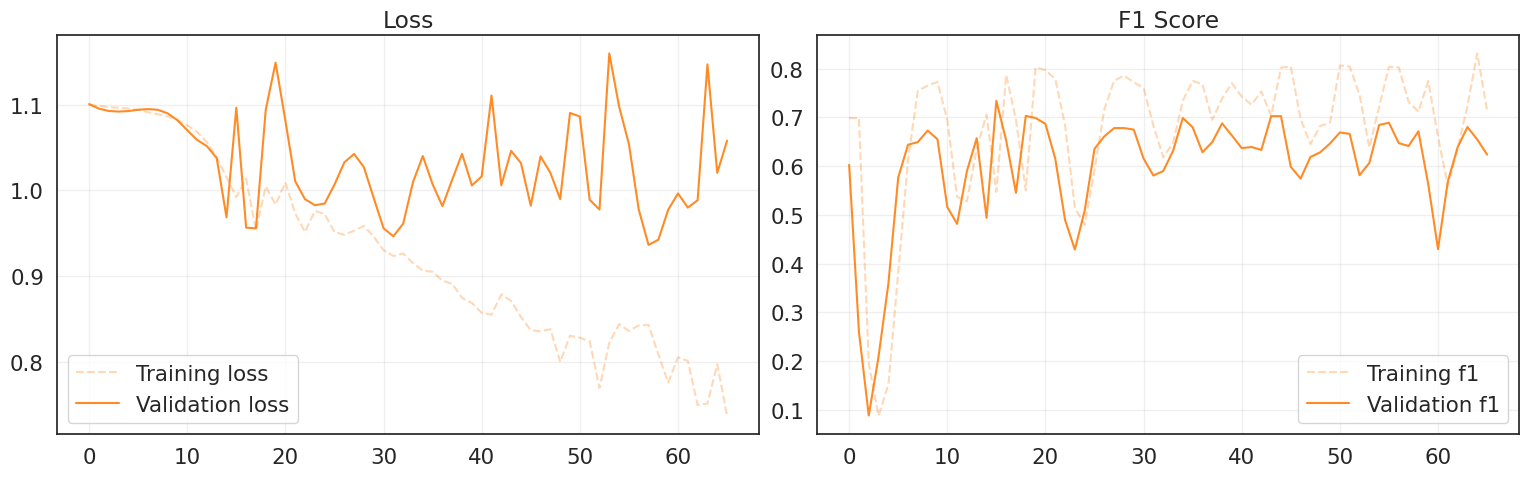

In [199]:
# @title Plot Hitory
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

### Plot Confusion Matrix

Accuracy over the validation set: 0.7803
Precision over the validation set: 0.7519
Recall over the validation set: 0.7803
F1 score over the validation set: 0.7338


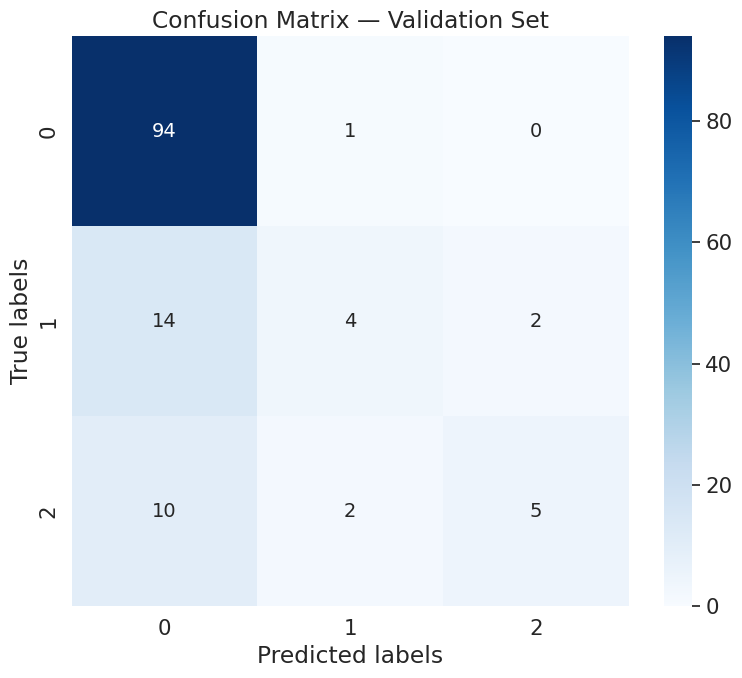

In [200]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## best_model.eval()
test_predictions = []

with torch.no_grad():
    for sequence in X_test_tensor:
        logits = best_model(sequence.unsqueeze(0))  # add batch dimension
        pred_class = torch.argmax(logits, dim=1).item()
        test_predictions.append(pred_class)Submission

In [204]:
from datetime import datetime

test_sequences = [
    group.sort_values("time")[feature_cols].values
    for _, group in df_public_test.groupby("sample_index")
]

test_sample_indices = df_public_test["sample_index"].unique()

# Convert to numpy (num_samples, seq_len, num_features)
X_test = np.array(test_sequences, dtype=np.float32)

# Convert to tensor for model
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# Make predictions
best_model.eval()
test_predictions = []

with torch.no_grad():
    for sequence in X_test_tensor:
        logits = best_model(sequence.unsqueeze(0))
        pred_class = torch.argmax(logits, dim=1).item()
        test_predictions.append(pred_class)

inverse_label_mapping = {v: k for k, v in label_mapping.items()}

predicted_labels = [inverse_label_mapping[p] for p in test_predictions]

submission_df = pd.DataFrame({
    "sample_index": test_sample_indices,
    "label": predicted_labels
})

submission_df.to_csv(f"{datetime.now()}_submission.csv", index=False)
print("submission.csv created successfully!")
print(submission_df.head())


submission.csv created successfully!
   sample_index    label
0             0  no_pain
1             1  no_pain
2             2  no_pain
3             3  no_pain
4             4  no_pain
